# Incremental Capstone Unit 5: What Are Customers Really Saying?

**Instructor:** Abishek Ganesh

**Your Name:** _______________  
**Your Role:** NLP Specialist  
**Client:** ShopSmart (Fashion E-Commerce Division)  
**Due Date:** Thursday, April 30, 2026

---

## The Brief

ShopSmart's fashion e-commerce division is scaling fast. Thousands of customer reviews are pouring in across every product category, and the product team is **drowning**. They can't manually read thousands of reviews to figure out what's working and what's broken.

**Your mission:** Build a sentiment analysis tool that automatically classifies review sentiment, then use it to deliver a **Sentiment Intelligence Report** with actionable insights for leadership.

This isn't just about building models. It's about building something **useful**.

### What You'll Deliver

| Part | What You Build | Points |
|------|---------------|--------|
| 1 | Text exploration & cleaning pipeline | 15 |
| 2 | Word embeddings trained on ShopSmart reviews | 20 |
| 3 | Deep learning sentiment classifier | 20 |
| 4 | BERT-powered classifier (state-of-the-art) | 20 |
| 5 | **Sentiment Intelligence Report for leadership** | 25 |

### Important Notes

- This is a **3-class** classification problem: positive, negative, neutral
- Use the **same train/test split** across all models
- **Set random seeds** for reproducibility
- Written reflections are **required** and graded (15% of your score)

### Grading

| Component | Weight |
|-----------|--------|
| Correctness | 70% |
| Code Quality | 15% |
| Reflection Quality | 15% |

## Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, string
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from gensim.models import Word2Vec

np.random.seed(42)
pd.set_option('display.max_colwidth', 100)
print('All imports loaded!')

All imports loaded!


---
## Part 1: Text Exploration & Preprocessing (15 pts)

ShopSmart has handed you ~6,000 customer reviews. Understand the data and clean it up before building anything.

### Task 1.1: Load and Explore

In [3]:
def load_reviews(filepath):
    """Load the ShopSmart fashion reviews dataset."""
    return pd.read_csv(filepath)

df = load_reviews('shopsmart_fashion_reviews.csv')
print(f'Dataset shape: {df.shape}')
df.head()


Dataset shape: (6000, 8)


,review_id,customer_id,product_category,review_text,star_rating,sentiment,review_date,verified_purchase
0,832,1583,Sandal,The sandal arrived on time nad matches the description. Material is thinner than I expected.,4,positive,2026-03-08,True
1,4241,1907,Trouser,Huge letdown.,1,negative,2025-10-24,False
2,5595,38,Coat,"Wore this coat a few times. It's fine, nothing special.",3,positive,2026-01-14,False
3,4711,1045,Sneaker,Average sneaker. I don't love it but I don't hate it. Not blown away by this sneaker but I'll ke...,3,neutral,2025-12-19,True
4,5466,1789,Sneaker,This sneaker is a three out of five for me. Sizing runs slightly large.,3,neutral,2025-09-29,True


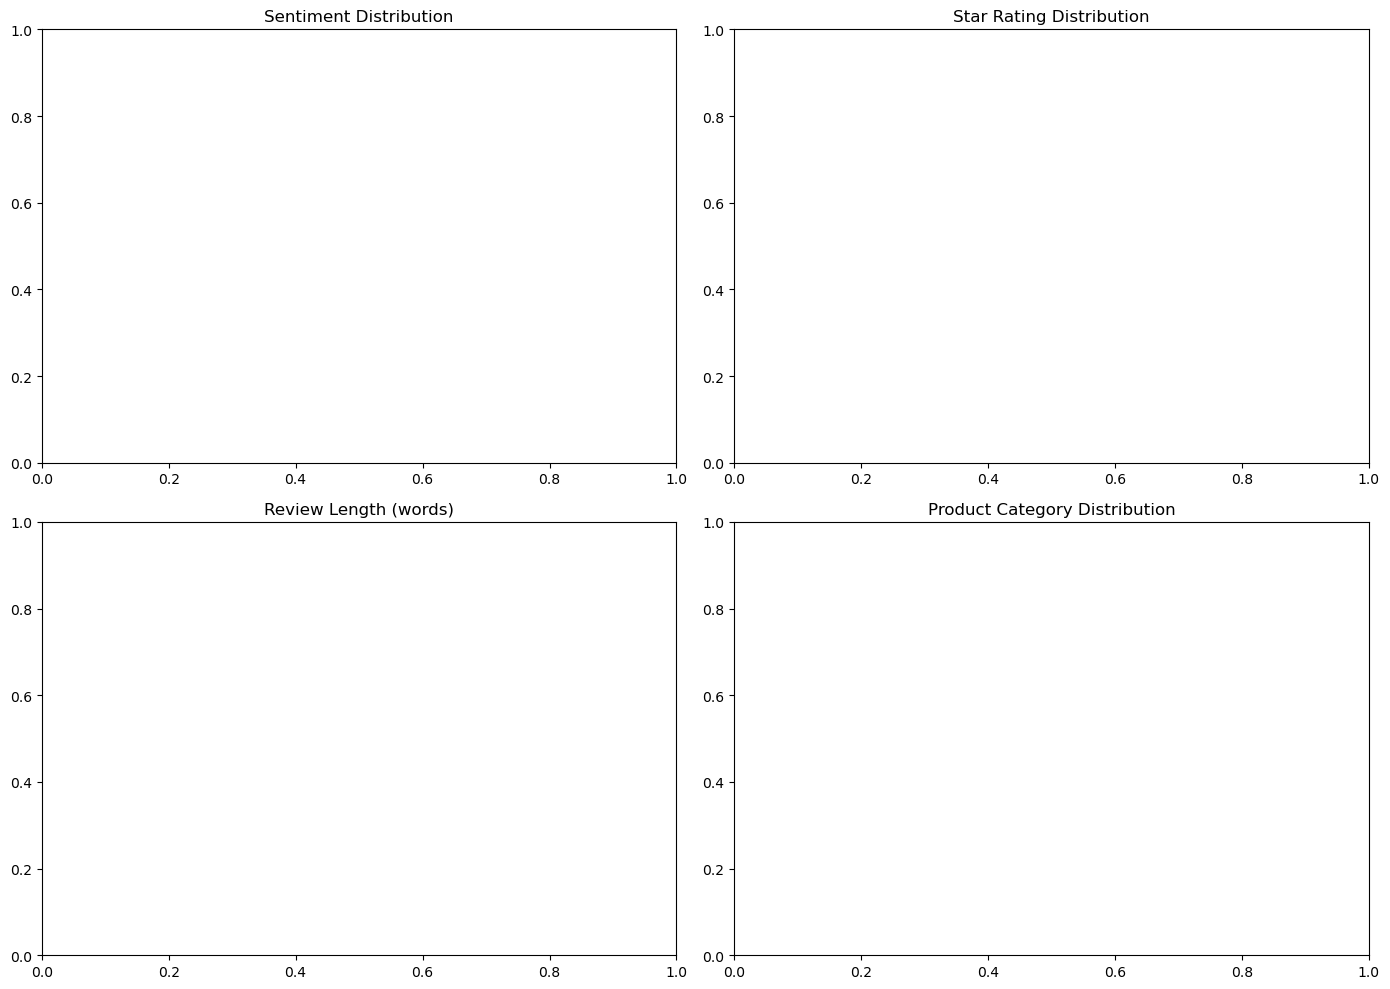

Sentiment distribution:
sentiment
positive    2649
negative    1791
neutral     1560
Name: count, dtype: int64

Average review length: 13.8 words


In [4]:
# Explore the dataset

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Sentiment distribution
# YOUR CODE: Use df['sentiment'].value_counts().plot(kind='bar', ax=axes[0,0])

axes[0,0].set_title('Sentiment Distribution')

# 2. Star rating distribution
# YOUR CODE: Use df['star_rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0,1])

axes[0,1].set_title('Star Rating Distribution')

# 3. Review length (words per review)
# YOUR CODE: Create a new column with word count: df['review_text'].str.split().str.len()
# Then plot a histogram with ax=axes[1,0]

axes[1,0].set_title('Review Length (words)')

# 4. Product category distribution
# YOUR CODE: Use df['product_category'].value_counts().plot(kind='bar', ax=axes[1,1])

axes[1,1].set_title('Product Category Distribution')

plt.tight_layout()
plt.show()

# Print summary stats
print(f'Sentiment distribution:\n{df["sentiment"].value_counts()}\n')
print(f'Average review length: {df["review_text"].str.split().str.len().mean():.1f} words')


### Task 1.2: Text Cleaning Pipeline

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    """Clean a single review."""
    # Step 1: Lowercase the text
    # YOUR CODE: text = text.lower()
    
    # Step 2: Remove punctuation and special characters
    # YOUR CODE: Use re.sub() to keep only letters and spaces
    # Hint: re.sub(r'[^\w\s]', '', text) removes non-word, non-space chars
    
    # Step 3: Remove numbers
    # YOUR CODE: re.sub(r'\d+', '', text)
    
    # Step 4: Remove emojis/non-ASCII characters
    # YOUR CODE: text = text.encode('ascii', 'ignore').decode('ascii')
    
    # Step 5: Split into words
    # YOUR CODE: words = text.split()
    
    # Step 6: Remove stopwords and short words, then lemmatize
    # YOUR CODE: Keep only words that are NOT in stop_words and len > 1
    # Apply lemmatizer.lemmatize(word) to each remaining word
    
    # Step 7: Join back into a string
    # YOUR CODE: return ' '.join(words)
    pass


# Test your function
test_text = "I LOVE this dress!!! It's absolutely GORGEOUS and fits perfectly."
print(f'Original: {test_text}')
print(f'Cleaned:  {clean_text(test_text)}')

# Expected output should be something like: love dress absolutely gorgeous fit perfectly


### Task 1.3: Preprocess All Reviews

In [ ]:
def preprocess_reviews(df):
    """Apply clean_text to all reviews. Add 'cleaned_text' column."""
    # YOUR CODE HERE
    pass

df_processed = preprocess_reviews(df)

for i in range(3):
    print(f'\nOriginal: {df_processed["review_text"].iloc[i][:100]}...')
    print(f'Cleaned:  {df_processed["cleaned_text"].iloc[i][:100]}...')

### Task 1.4: Word Frequency Analysis

In [ ]:
# Word frequency analysis: What words define each sentiment?

sentiment_classes = ['positive', 'negative', 'neutral']

for sentiment in sentiment_classes:
    # Step 1: Filter cleaned_text for this sentiment
    # YOUR CODE: Get all cleaned_text where df_processed['sentiment'] == sentiment
    sentiment_texts = None  # Replace

    # Step 2: Combine all texts into one big string, then split into words
    # YOUR CODE: Join all texts with spaces, then .split() into a list of words
    all_words = None  # Replace

    # Step 3: Count word frequencies using Counter
    # YOUR CODE: Use Counter(all_words).most_common(20) to get top 20
    top_20 = None  # Replace

    # Print results
    print(f'\n=== {sentiment.upper()} (top 20 words) ===')
    for word, count in top_20:
        print(f'  {word:20s} {count}')


### Task 1.5: Train/Test Split

**Use this exact split for ALL models.**

In [ ]:
label_encoder = LabelEncoder()
df_processed['sentiment_encoded'] = label_encoder.fit_transform(df_processed['sentiment'])
print(f'Label mapping: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}')

X_text = df_processed['cleaned_text']
y = df_processed['sentiment_encoded']

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {len(X_train_text)} | Test: {len(X_test_text)}')

### Part 1 Reflection

**Q1:** What patterns do you notice in word frequencies for positive vs negative reviews?

**Q2:** How does working with text data differ from the numerical data in Units 3 and 4?

**A1:** 

**A2:** 

---
## Part 2: Word Embeddings (20 pts)

You'll train a **Word2Vec** model directly on ShopSmart's reviews. Unlike generic embeddings, this model will learn what words mean *in the context of fashion retail*. "Comfortable" and "cozy" will be close together. "Cheap" might be near both "affordable" and "low-quality."

This is your model learning ShopSmart's language.

### Task 2.1: Train Word2Vec

In [ ]:
def train_word2vec(texts, vector_size=100, window=5, min_count=2):
    """Train Word2Vec on the provided texts. Tokenize each text by splitting on spaces."""
    # Step 1: Convert each text string into a list of words
    # Hint: sentences = [text.split() for text in texts]

    # Step 2: Train Word2Vec(sentences, vector_size=..., window=..., min_count=..., seed=42)
    # YOUR CODE HERE
    pass


# Train on ALL cleaned reviews (embeddings aren't labels) 
w2v_model = train_word2vec(df_processed['cleaned_text'].values, vector_size=100)
print(f'Vocabulary: {len(w2v_model.wv)} words, dim={w2v_model.wv.vector_size}')


### Task 2.2: Explore What the Model Learned

In [ ]:
# YOUR CODE: Explore word relationships
# 1. most_similar('comfortable'), most_similar('terrible'), most_similar('dress'), most_similar('quality')
# 2. Try analogies: most_similar(positive=[...], negative=[...])
# 3. doesnt_match(['dress', 'shirt', 'sneaker', 'terrible'])
# 4. What fashion-specific relationships did it learn?


### Task 2.3: Document Embeddings

In [ ]:
def get_document_embedding(text, model, vector_size=100):
    """Average word vectors for all words in text. Return zeros if no words found."""
    words = text.split()
    wv = model.wv if hasattr(model, 'wv') else model

    # YOUR CODE: Build a list of vectors for words that exist in the model
    # Hint: check if a word is in the vocabulary with `if w in wv`
    # Then get its vector with wv[w]

    # If no words were found, return np.zeros(vector_size)
    # Otherwise, return np.mean of the vectors (axis=0)
    pass


def create_embedding_features(texts, model, vector_size=100):
    """Create embedding features for a list of texts. Returns (n_samples, vector_size) array."""
    # YOUR CODE: Apply get_document_embedding to each text and stack into a numpy array
    # Hint: np.array([get_document_embedding(t, model, vector_size) for t in texts])
    pass


X_train_emb = create_embedding_features(X_train_text.values, w2v_model)
X_test_emb = create_embedding_features(X_test_text.values, w2v_model)
print(f'Embedding features: {X_train_emb.shape}')


### Task 2.4: Classify with Embeddings

In [ ]:
# Train a Logistic Regression classifier on the embedding features

# Step 1: Create the model
# YOUR CODE: lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Step 2: Fit on training data
# YOUR CODE: lr_model.fit(X_train_emb, y_train)

# Step 3: Predict on test data
# YOUR CODE: y_pred_emb = lr_model.predict(X_test_emb)

# Step 4: Calculate metrics (use average='weighted' for multi-class!)
embedding_metrics = {
    'accuracy': None,
    'precision': None,
    'recall': None,
    'f1': None,
}

print(f"Word2Vec + LR Accuracy: {embedding_metrics['accuracy']:.4f}")
print(f"Word2Vec + LR F1: {embedding_metrics['f1']:.4f}")


### Part 2 Reflection

**Q1:** What interesting word relationships did your model learn? Anything fashion-specific?

**Q2:** Why might averaging word vectors lose important information?

**A1:** 

**A2:** 

---
## Part 3: Deep Learning for Text (20 pts)

Word2Vec averages throw away word order. "Not good" and "good not" produce the same result. Build a neural network that processes reviews as **sequences**, learning its own task-specific embeddings.

In [ ]:
import tensorflow as tf
tf.random.set_seed(42)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, Dropout, GlobalAveragePooling1D, LSTM, Flatten
from tensorflow.keras.callbacks import EarlyStopping
print('TensorFlow loaded!')

### Task 3.1: Prepare Sequences

In [ ]:
def prepare_sequences(texts, max_words=10000, max_len=100):
    """Convert raw text into padded integer sequences for a neural network.
    
    Neural networks can't read words — they need numbers. This function:
    1. Assigns each word a unique integer (tokenization)
    2. Converts each review into a list of integers
    3. Pads/truncates so every review is the same length
    """
    # Step 1: Create a Tokenizer that keeps only the top max_words
    # Hint: Tokenizer(num_words=max_words, oov_token='<OOV>')
    # The oov_token handles words the tokenizer hasn't seen

    # Step 2: Fit the tokenizer on the texts (learns the vocabulary)
    # Hint: tokenizer.fit_on_texts(texts)

    # Step 3: Convert texts to sequences of integers
    # Hint: sequences = tokenizer.texts_to_sequences(texts)

    # Step 4: Pad sequences so they're all the same length
    # Hint: pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

    # YOUR CODE HERE
    pass  # Return (padded_sequences, tokenizer)


MAX_WORDS = 10000
MAX_LEN = 100

X_train_seq, tokenizer = prepare_sequences(X_train_text.values, MAX_WORDS, MAX_LEN)
# IMPORTANT: Use the SAME tokenizer for test data
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test_text.values), maxlen=MAX_LEN)

print(f'Sequence shape: {X_train_seq.shape}')
print(f'Vocabulary size: {min(len(tokenizer.word_index) + 1, MAX_WORDS)}')


### Task 3.2: Build Text Neural Network

In [ ]:
def build_text_nn(vocab_size, embedding_dim=64, max_len=100):
    """Build a neural network for sentiment classification."""
    model = Sequential([
        # Layer 1: Embedding — turns word integers into dense vectors
        Embedding(vocab_size, embedding_dim, input_length=max_len),

        # Layer 2: GlobalAveragePooling1D — averages across the sequence
        # This collapses (max_len, embedding_dim) -> (embedding_dim,)
        GlobalAveragePooling1D(),

        # YOUR CODE: Add at least 2 Dense + Dropout hidden layers
        # Start with embedding_dim units and work down to the output
        # Then a final Dense(3, activation='softmax') for 3 sentiment classes

    ])

    # YOUR CODE: Compile — optimizer='adam', metrics=['accuracy']
    # Pick the right loss function for integer-encoded multi-class labels
    # model.compile(...)

    return model


vocab_size = min(len(tokenizer.word_index) + 1, MAX_WORDS)
text_model = build_text_nn(vocab_size, embedding_dim=64, max_len=MAX_LEN)
text_model.build(input_shape=(None, MAX_LEN))
text_model.summary()


### Task 3.3: Train and Evaluate

In [ ]:
# Train the model

# Set up early stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# YOUR CODE: Train the model using text_model.fit()
# Parameters:
#   - X_train_seq, y_train (training data)
#   - validation_data=(X_test_seq, y_test)
#   - epochs=20
#   - batch_size=32
#   - callbacks=[early_stop]

history = None  # Replace with text_model.fit(...)


In [ ]:
# Plot training curves

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history.history['accuracy'], label='Train Acc')
ax2.plot(history.history['val_accuracy'], label='Val Acc')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()


In [ ]:
y_pred_nn = text_model.predict(X_test_seq).argmax(axis=1)

nn_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_nn),
    'precision': precision_score(y_test, y_pred_nn, average='weighted'),
    'recall': recall_score(y_test, y_pred_nn, average='weighted'),
    'f1': f1_score(y_test, y_pred_nn, average='weighted'),
}

print(f"Text NN Accuracy: {nn_metrics['accuracy']:.4f}")
print(f"Word2Vec + LR:    {embedding_metrics['accuracy']:.4f}")
print(f"Text NN:          {nn_metrics['accuracy']:.4f}")

### Part 3 Reflection

**Q1:** Compare training curves to your Unit 4 tabular NNs. What's similar/different?

**Q2:** Why does learning task-specific embeddings sometimes outperform pre-trained Word2Vec?

**A1:** 

**A2:** 

---
## Part 4: Transfer Learning with BERT (20 pts)

Everything so far learned from only 6,000 reviews. **BERT** was pre-trained on **billions of words**. It already understands language deeply. We just point it at ShopSmart's reviews.

We'll use `distilbert-base-uncased` -- a smaller, faster BERT retaining 97% of performance.

In [ ]:
# !pip install transformers torch
from transformers import AutoTokenizer, AutoModel
import torch
print(f'PyTorch: {torch.__version__}')

### Task 4.1: Extract BERT Embeddings

In [ ]:
def get_bert_embeddings(texts, model_name='distilbert-base-uncased', batch_size=32, max_length=128):
    """Extract BERT [CLS] token embeddings."""

    # Step 1: Load tokenizer and model from HuggingFace
    # YOUR CODE:
    # tokenizer_bert = AutoTokenizer.from_pretrained(model_name)
    # model_bert = AutoModel.from_pretrained(model_name)
    # model_bert.eval()  # Set to evaluation mode (no dropout)

    all_embeddings = []

    # Step 2: Process texts in batches (BERT is memory-hungry)
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]

        # Step 3: Tokenize the batch
        # YOUR CODE: Use the tokenizer with padding=True, truncation=True,
        #            max_length=max_length, return_tensors='pt'
        # encoded = tokenizer_bert(batch, ...)

        # Step 4: Run through BERT (no gradients needed - saves memory)
        # YOUR CODE:
        # with torch.no_grad():
        #     outputs = model_bert(**encoded)

        # Step 5: Extract [CLS] token embedding (first token of last hidden state)
        # YOUR CODE: cls_embeddings = outputs.last_hidden_state[:, 0, :].numpy()

        # all_embeddings.append(cls_embeddings)

        if (i // batch_size) % 20 == 0:
            print(f'  Processed {min(i + batch_size, len(texts))}/{len(texts)} texts...')

    # Step 6: Stack all batches into one array
    # YOUR CODE: return np.concatenate(all_embeddings, axis=0)
    pass


# This will take a few minutes
print('Extracting BERT embeddings for training data...')
bert_train_embeddings = get_bert_embeddings(X_train_text.values.tolist())
print(f'Train shape: {bert_train_embeddings.shape}')

print('Extracting BERT embeddings for test data...')
bert_test_embeddings = get_bert_embeddings(X_test_text.values.tolist())
print(f'Test shape: {bert_test_embeddings.shape}')


### Task 4.2: Train BERT Classifier

In [ ]:
def train_bert_classifier(X_train, y_train, X_test, y_test):
    """Train Logistic Regression on BERT embeddings. Return dict with accuracy, precision, recall, f1, model."""
    # YOUR CODE HERE
    pass

bert_metrics = train_bert_classifier(bert_train_embeddings, y_train, bert_test_embeddings, y_test)

print(f"\n--- All Models ---")
print(f"Word2Vec + LR: {embedding_metrics['accuracy']:.4f}")
print(f"Text NN:       {nn_metrics['accuracy']:.4f}")
print(f"BERT + LR:     {bert_metrics['accuracy']:.4f}")

In [ ]:
# BERT confusion matrix

y_pred_bert = bert_metrics['model'].predict(bert_test_embeddings)

cm = confusion_matrix(y_test, y_pred_bert)
disp = ConfusionMatrixDisplay(cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Blues')
plt.title('BERT Sentiment Classifier - Confusion Matrix')
plt.show()


### Part 4 Reflection

**Q1:** Why is BERT so much more powerful? What does pre-training on billions of words give you?

**Q2:** What are the production trade-offs of BERT vs simpler models?

**Q3:** Explain transfer learning to ShopSmart's CEO in 2 sentences.

**A1:** 

**A2:** 

**A3:** 

---
## Part 5: ShopSmart Sentiment Intelligence Report (25 pts)

You've built the tool. Now **use it**.

ShopSmart leadership doesn't care about F1 scores. They care about **which products have problems**, **what customers are complaining about**, and **what to do about it**.

### Task 5.1: Prediction Pipeline

In [ ]:
def predict_sentiment(texts):
    """Predict sentiment for raw review texts. Returns list of labels.
    
    This is your production pipeline — it takes raw text (like a customer
    would write it) and returns a sentiment label. No preprocessing
    should be needed by the caller.
    """
    # Step 1: Clean the raw text using your clean_text function
    # Hint: cleaned = [clean_text(t) for t in texts]

    # Step 2: Get BERT embeddings for the cleaned texts
    # Hint: Use your get_bert_embeddings() function

    # Step 3: Predict using your trained BERT classifier
    # Hint: best_model.predict(embeddings) returns integer labels

    # Step 4: Convert integer labels back to strings
    # Hint: label_encoder.inverse_transform() converts ints -> 'positive'/'negative'/'neutral'

    # YOUR CODE HERE
    pass


# Test on new reviews ShopSmart might receive tomorrow
test_reviews = [
    "Absolutely love this jacket! Perfect fit and great quality.",
    "Terrible product, fell apart after one wash. Want my money back.",
    "It's okay I guess. Nothing special but it works.",
    "The sneakers are SO comfortable!! Best purchase all year",
    "Wrong size, wrong color, took 3 weeks to arrive. Awful."
]
predictions = predict_sentiment(test_reviews)
for review, pred in zip(test_reviews, predictions):
    print(f'[{pred:>8}] {review[:70]}')


### Task 5.2: Sentiment by Product Category

In [ ]:
def category_sentiment_summary(df):
    """Sentiment breakdown by category: counts, percentages, avg star rating."""

    # Step 1: Group by product_category and count each sentiment
    # YOUR CODE: Use df.groupby('product_category').agg(...)
    # You'll need:
    #   total_reviews = ('sentiment', 'count')
    #   positive_count = ('sentiment', lambda x: (x == 'positive').sum())
    #   negative_count = ('sentiment', lambda x: (x == 'negative').sum())
    #   neutral_count = ('sentiment', lambda x: (x == 'neutral').sum())
    #   avg_stars = ('star_rating', 'mean')
    summary = None  # Replace with groupby

    # Step 2: Calculate percentages
    # YOUR CODE:
    # summary['positive_pct'] = (summary['positive_count'] / summary['total_reviews'] * 100).round(1)
    # summary['negative_pct'] = ...
    # summary['neutral_pct'] = ...

    # Step 3: Sort by negative_pct descending (worst categories first)
    # YOUR CODE: return summary.sort_values('negative_pct', ascending=False)
    pass


sentiment_report = category_sentiment_summary(df_processed)
sentiment_report


In [ ]:
# Visualize sentiment by category

# YOUR CODE: Create a stacked bar chart showing positive/negative/neutral % per category
# Hint: Use sentiment_report.plot(kind='barh') or sns.heatmap()
#
# Example approach:
# sentiment_report.set_index('product_category')[['positive_pct', 'neutral_pct', 'negative_pct']].plot(
#     kind='barh', stacked=True, figsize=(10, 6), color=['#2ecc71', '#f39c12', '#e74c3c']
# )
# plt.xlabel('Percentage of Reviews')
# plt.title('Sentiment Breakdown by Product Category')
# plt.legend(title='Sentiment')
# plt.tight_layout()
# plt.show()


### Task 5.3: Top Complaints

In [ ]:
def identify_top_complaints(df, n=10):
    """Extract most common complaint themes from negative reviews."""

    # Step 1: Filter to only negative reviews
    # YOUR CODE: Get the cleaned_text for rows where sentiment == 'negative'

    # Step 2: Combine all negative review text and split into words
    # Hint: ' '.join(negative_texts).split()

    # Step 3: Count word frequencies using Counter
    # Hint: Counter(all_words).most_common(n)

    # Step 4: Build a DataFrame with the results
    # Columns: 'complaint_theme' and 'frequency'

    # YOUR CODE HERE
    pass


top_complaints = identify_top_complaints(df_processed)
top_complaints


### Task 5.4: Sentiment Trends

In [ ]:
# Sentiment trends over time

# Step 1: Convert review_date to datetime and extract month
# YOUR CODE:
# df_processed['review_month'] = pd.to_datetime(df_processed['review_date']).dt.to_period('M')

# Step 2: Count reviews by month and sentiment
# YOUR CODE:
# trends = df_processed.groupby(['review_month', 'sentiment']).size().unstack(fill_value=0)

# Step 3: Convert to percentages
# YOUR CODE:
# trends_pct = trends.div(trends.sum(axis=1), axis=0) * 100

# Step 4: Plot it
# YOUR CODE:
# trends_pct.plot(kind='line', figsize=(10, 5), marker='o')
# plt.title('Sentiment Trends Over Time')
# plt.ylabel('Percentage of Reviews')
# plt.xlabel('Month')
# plt.legend(title='Sentiment')
# plt.show()

# Are any categories trending in the wrong direction?
# YOUR CODE (optional): Group by category + month and check for declining sentiment


### Task 5.5: Executive Summary

This is what ShopSmart leadership actually reads.

## ShopSmart Fashion: Sentiment Intelligence Report

### Overview
*(What you analyzed, how many reviews, what time period)*

### Key Findings
1. 
2. 
3. 

### Categories Requiring Attention

### Recommended Actions
1. 
2. 
3. 

### Using This Tool Going Forward

### Part 5 Reflection

**Q1:** Top 3 actionable insights for ShopSmart leadership?

**Q2:** Which product categories need immediate attention and why?

**Q3:** How could ShopSmart use this tool on an ongoing basis?

**A1:** 

**A2:** 

**A3:** 

---
## Submission Checklist

- [ ] Part 1: `load_reviews`, `clean_text`, `preprocess_reviews` + reflections
- [ ] Part 2: Word2Vec trained + embedding classifier + reflections
- [ ] Part 3: Text NN with Embedding layer + training curves + reflections
- [ ] Part 4: BERT embeddings + classifier + reflections
- [ ] Part 5: `predict_sentiment` + category analysis + complaints + executive summary + reflections
- [ ] All cells run (Kernel > Restart & Run All)
- [ ] All reflections answered thoughtfully